# RMSprop Gradient Descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Define quadratic loss function and its gradient

In [2]:
def quadratic_loss(x,y):
    return x**2 + 10 * y**2

In [3]:
def quadratic_grad(x, y):
    dx = 2 * x
    dy = 20 * y
    return np.array([dx, dy])

## Vanilla GD

In [4]:
def gradient_descent(grad_func, lr, epochs, start_point):
    x, y = start_point
    path = [(x, y)]
    losses = [quadratic_loss(x,y)]

    for _ in range(epochs):
        grad = grad_func(x,y)
        x -= lr * grad[0]
        y -= lr * grad[1]
        path.append((x,y))
        losses.append(quadratic_loss(x,y))

    return np.array(path), losses


## RMSprop

In [5]:
def rmsprop_optimizer(grad_func, lr, beta, epsilon, epochs, start_point):
    x,y = start_point
    Eg2 = np.array([0.0, 0.0]) #Moving average of squared gradients
    path = [(x,y)]
    losses = [quadratic_loss(x, y)]

    for _ in range(epochs):
        grad = grad_func(x, y) # Compute gradients
        Eg2 = beta * Eg2 + (1-beta) * (grad ** 2) # Update moving average

        x -= lr * grad[0] / (np.sqrt(Eg2[0]) + epsilon) #Update x
        y -= lr * grad[1] / (np.sqrt(Eg2[1]) + epsilon) #Update y

        path.append((x,y))
        losses.append(quadratic_loss(x,y))

    return np.array(path), losses
        

## Visualization of paths and losses

In [6]:
def plot_paths(function, paths, labels, title):
    X,Y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
    Z = function(X, Y)

    plt.figure(figsize=(8,6)) # 8*6 inch
    plt.contour(X, Y, Z, levels=50, cmap='jet')#50 countour levels, rainbow color

    for path, label in zip(paths, labels):
        plt.plot(path[:,0], path[:, 1], label=label)
        '''
        path[:,0] x coordinates of all points
        path[:,1] y coordinates of all points
        plt.plot(x, y) connect the lines and draw
        '''
        plt.scatter(path[0,0], path[0,1], color='green', label='Start')#Start point
        plt.scatter(path[-1,0], path[-1,1], color='red', label='End')#End point

    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()
        

In [7]:
def plot_losses(losses, labels, title):
    plt.figure(figsize=(8,6))

    for loss, label in zip(losses, labels):
        plt.plot(loss, label=label)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
    

## Parameters

In [8]:
lr_gd = 0.01 #Learning rate for GD
lr_rmsprop = 0.01 #Learning rate for RMSprop
beta = 0.9 #Decay rate for RMSprop
epsilon = 1e-8 # Small constant for RMSprop
epochs = 200
start_point = (1.5, 1.5) #Initial point from the minimum

## Run optimizations

In [9]:
path_gd, losses_gd = gradient_descent(quadratic_grad, lr_gd, epochs, start_point)
path_rmsprop, losses_rmsprop = rmsprop_optimizer(quadratic_grad, lr_rmsprop, beta, epsilon, epochs, start_point)


## Plot results

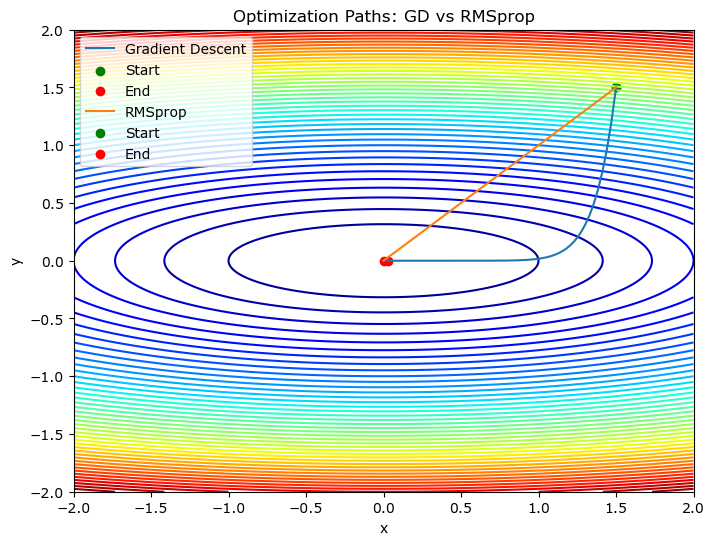

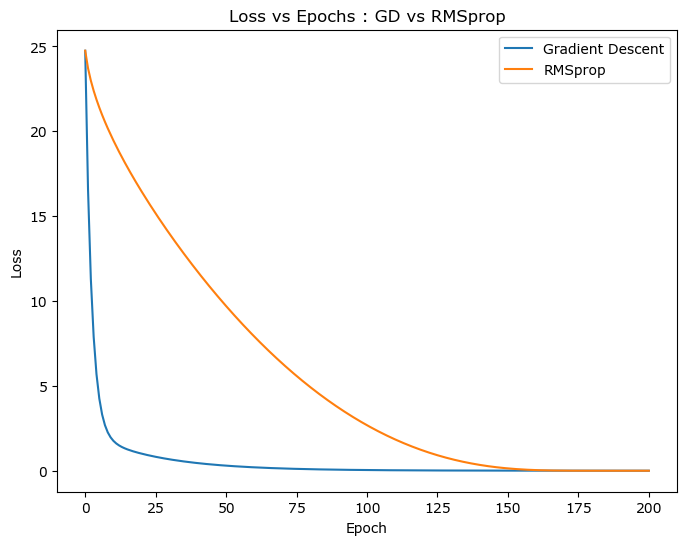

In [10]:
plot_paths(quadratic_loss, [path_gd, path_rmsprop],["Gradient Descent","RMSprop"],"Optimization Paths: GD vs RMSprop")
plot_losses([losses_gd, losses_rmsprop], ["Gradient Descent", "RMSprop"], "Loss vs Epochs : GD vs RMSprop")

### Chosing a proper learning rate is important, so that it balances the convergence speed and avoidance of oscillations (In VanillaGD). The RMSprop takes the moving average of the square of the gradient, so if gradient is small, it will be normalized to a higher value; vise versa, the learning rate is adaptive.